<a href="https://colab.research.google.com/github/nunez1405/Data-science-projects/blob/main/ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ecommerce Costumer Behaviour Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhairyajeetsingh/ecommerce-customer-behavior-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-customer-behavior-dataset' dataset.
Path to dataset files: /kaggle/input/ecommerce-customer-behavior-dataset


In [ ]:
import os
os.listdir(path)


['ecommerce_customer_churn_dataset.csv']

In [ ]:
df = pd.read_csv(os.path.join(path, 'ecommerce_customer_churn_dataset.csv'))

In [ ]:
display(df.head())

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


Start to cook

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [ ]:
for col in df.columns:
    print(col, df[col].nunique())

Age 62
Gender 3
Country 8
City 40
Membership_Years 200
Login_Frequency 46
Session_Duration_Avg 658
Pages_Per_Session 224
Cart_Abandonment_Rate 1000
Wishlist_Items 25
Total_Purchases 150
Average_Order_Value 16407
Days_Since_Last_Purchase 235
Discount_Usage_Rate 1727
Returns_Rate 394
Email_Open_Rate 720
Customer_Service_Calls 21
Product_Reviews_Written 18
Social_Media_Engagement_Score 972
Mobile_App_Usage 540
Payment_Method_Diversity 5
Lifetime_Value 45447
Credit_Balance 5234
Churned 2
Signup_Quarter 4


In [ ]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [ ]:
print(df.isnull().sum())
print(len(df))

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64
50000


Hay columnas con muchos valores nulos, habrá que identificar cual sería el reemplazo ideal, si la moda, la mediana o eliminar la fila. También sería ideal si podemos armar un pipeline para visualizar el modelo de flujo del modelo. Dividimos todas las columnas en la categoría correspondiente a transformar

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Session_Duration_Avg'] = df['Session_Duration_Avg'].fillna(df['Session_Duration_Avg'].mean())
df['Pages_Per_Session'] = df['Pages_Per_Session'].fillna(df['Pages_Per_Session'].mean())
df['Wishlist_Items'] = df['Wishlist_Items'].fillna(df['Wishlist_Items'].mean())
df['Days_Since_Last_Purchase'] = df['Days_Since_Last_Purchase'].fillna(df['Days_Since_Last_Purchase'].mean())
df['Discount_Usage_Rate'] = df['Discount_Usage_Rate'].fillna(df['Discount_Usage_Rate'].mean())
df['Returns_Rate'] = df['Returns_Rate'].fillna(df['Returns_Rate'].mean())
df['Email_Open_Rate'] = df['Email_Open_Rate'].fillna(df['Email_Open_Rate'].mean())
df['Customer_Service_Calls'] = df['Customer_Service_Calls'].fillna(df['Customer_Service_Calls'].mean())
df['Product_Reviews_Written'] = df['Product_Reviews_Written'].fillna(df['Product_Reviews_Written'].mean())
df['Social_Media_Engagement_Score'] = df['Social_Media_Engagement_Score'].fillna(df['Social_Media_Engagement_Score'].mean())
df['Mobile_App_Usage'] = df['Mobile_App_Usage'].fillna(df['Mobile_App_Usage'].mean())
df['Payment_Method_Diversity'] = df['Payment_Method_Diversity'].fillna(df['Payment_Method_Diversity'].mean())
df['Credit_Balance'] = df['Credit_Balance'].fillna(df['Credit_Balance'].mean())


Chequeamos de vuelta

In [ ]:
print(df.isnull().sum())

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64


Empezamos con Machine Learning

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Clustering

Definimos características para el clustering separando columnas categoricas y numericas. Creamos un preprocesador de datos usando "ColumnTransformer" para aplicar "StandardScaler" para las categorías numericas y "OneHotEncoder" para las categorías categoricas. Luego, determinamos la canditad optimas de cluster para los Kmeans tras evaluar el puntaje de silueta para distintos valores K


## Definir características para el clustering

### Subtarea:

Identificar y separar las columnas numericas y categoricas que seran usadas para clusteing, excluimos churned que es la columna target.


**Razonamiento** :
Es ideal separar en categoricas y numericas para el preprocesamiento



In [ ]:
all_features = [col for col in df.columns if col != 'Churned']
numerical_features = df[all_features].select_dtypes(include=np.number).columns.tolist()
categorical_features = df[all_features].select_dtypes(include='object').columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']
Categorical features: ['Gender', 'Country', 'City', 'Signup_Quarter']


## Preprocesamiento de datos

### Subtarea:

Crear un pipeline de preprocesamiento de datos usando `ColumnTransformer` haciendo una estandarizacion de datos para numericos, y `OneHotEncoder` para categoricos. Manejar valores faltantes, pero ya fueron analizados.


In [ ]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_preprocessed = preprocessor.fit_transform(df)

print("Shape of preprocessed data:", X_preprocessed.shape)

Shape of preprocessed data: (50000, 75)


**Razonammiento**:

Ahora que los datos fueron preprocesados,iteraremos para un valor de k de 2 hasta 10, calculando la puntuacion de silueta para cada k y encontrando la mejor,



For k=2, Silhouette Score: 0.20549571940002145
For k=3, Silhouette Score: 0.10884277977955654
For k=4, Silhouette Score: 0.11072689916492415
For k=5, Silhouette Score: 0.0671999505492935
For k=6, Silhouette Score: 0.06456062034052291
For k=7, Silhouette Score: 0.0648261839462005
For k=8, Silhouette Score: 0.0477379443942347
For k=9, Silhouette Score: 0.06056918991193743
For k=10, Silhouette Score: 0.046277965787076


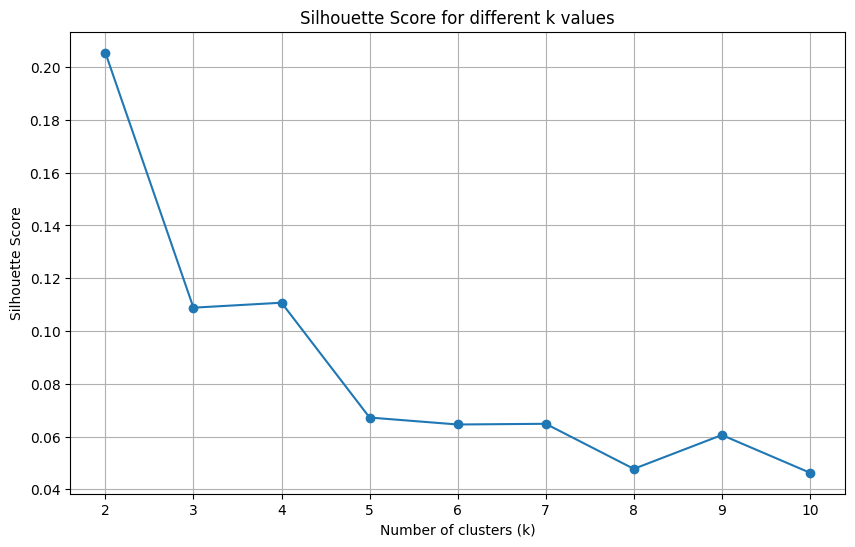

In [ ]:
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to 10 to suppress future warning
    kmeans.fit(X_preprocessed)
    score = silhouette_score(X_preprocessed, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"For k={k}, Silhouette Score: {score}")

# Plotting the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for different k values')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

## Elbow Method

### Subtarea:
También chequeamos el método de la inercia para verificiar si el k elegido es consistente con el coodo en la curva de inercia.

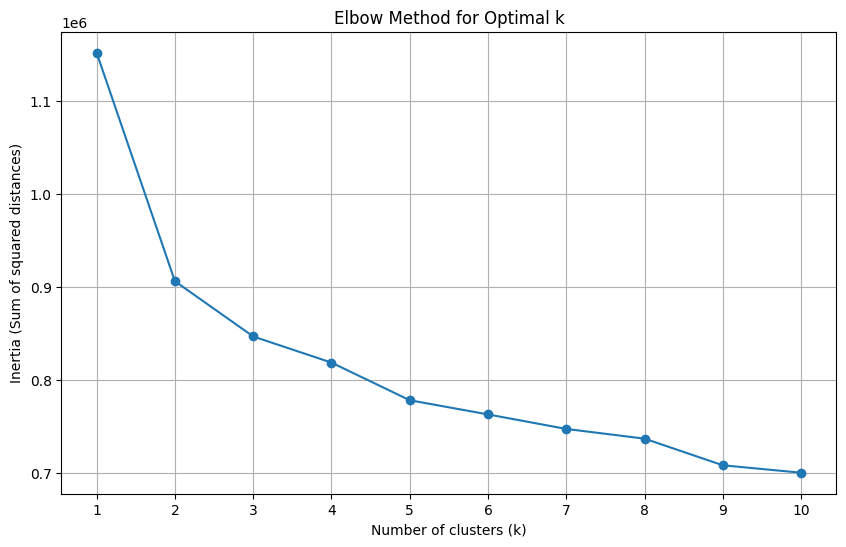

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_preprocessed)
    inertia.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


Basandonos en las puntuaciones de silueta, k = 2 muestra la puntuación de silueta, indicando que se ven mejor y mas separados cluster,s mientras la puntuacion de silueta no es parcticularmente alto, es la mejor en el rango elegido y testeado.

## Kmeans clustering

Instanciamos el modelo de Clustering con un k =  2 obtenido por el analisis previo por la curva de inercia.


In [ ]:
kmeans_optimal = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_optimal.fit(X_preprocessed)

print("KMeans model fitted successfully with 2 clusters.")

KMeans model fitted successfully with 2 clusters.


## Añadimos etiquetas al dataframe

Nueva columna con la etiqueta del clustering


To prepare for further analysis, I will use the fitted KMeans model to predict cluster labels for the preprocessed data and then assign these labels as a new 'Cluster' column to the original DataFrame.
Para analisis posteriores, usare el modelo entrado para predecir las etiquetas a la data preprocesada y luego asignar esas etiquetas como columna "Cluster" al Dataframe original.



In [ ]:
df['Cluster'] = kmeans_optimal.predict(X_preprocessed)
display(df.head())

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Cluster
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.000000,50.6,3.0,...,9.0,4.0,16.300000,20.8,1.000000,953.33,2278.0,0,Q1,1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.300000,37.7,1.0,...,7.0,3.0,29.364466,23.3,3.000000,1067.47,3028.0,0,Q4,0
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.600000,70.9,1.0,...,4.0,1.0,29.364466,8.8,2.353874,1289.75,2317.0,0,Q4,1
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.800000,41.7,9.0,...,2.0,5.0,85.900000,31.0,3.000000,2340.92,2674.0,0,Q1,0
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.737811,19.1,9.0,...,1.0,11.0,83.000000,50.4,4.000000,3041.29,5354.0,0,Q4,0


## Visualización de resultados
La exploración visual de resultados es fundamental para un buen analisis de clustering, nos permite ver y diferenciar si existe la segmentación de la data.



**Reasoning**:
To visualize the clusters, I will reduce the dimensionality of the preprocessed data using PCA to 2 components, create a DataFrame with the PCA components and cluster labels, and then plot the results using a scatter plot.
Ademas, usaremos el módelo de reducción de dimensionalidad a la data preprocesada usando PCA a dos componentes, creando un DataFrame con los componentes PCA con las etiquetas del cluster, luego graficamos con scatter plot



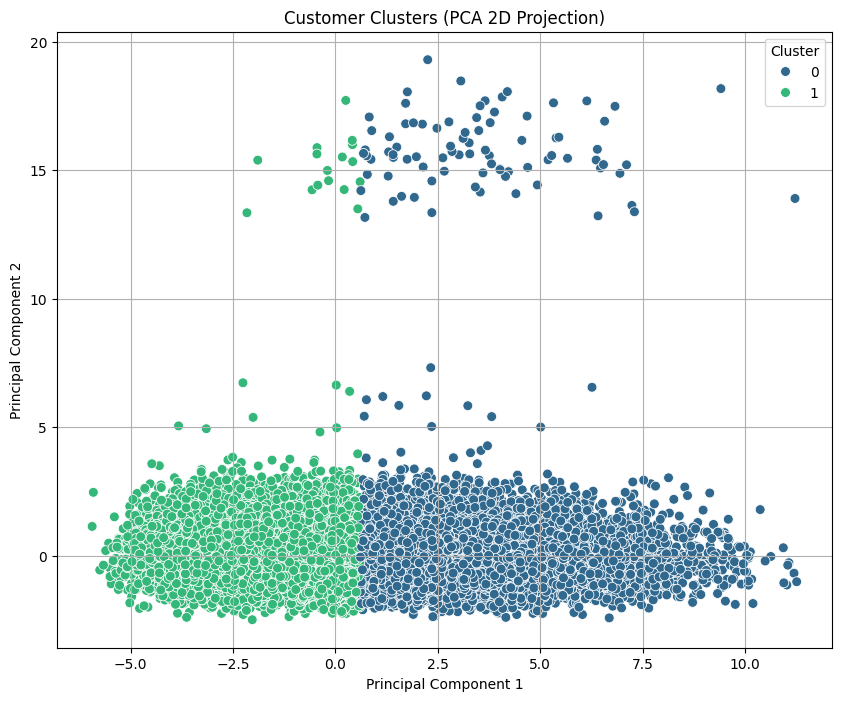

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA to the preprocessed data and transform it
X_pca = pca.fit_transform(X_preprocessed)

# Create a DataFrame from the PCA components
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Add the 'Cluster' column to the PCA DataFrame
pca_df['Cluster'] = df['Cluster']

# Plot the clusters using seaborn scatterplot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', legend='full', s=50)
plt.title('Customer Clusters (PCA 2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()